In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision import models
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

# تثبيت العشوائية لضمان تكرار النتائج (Reproducibility)
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# افترض أن البيانات موجودة في هذا المسار (Kaggle default)
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
all_image_paths = {}
for root, dirs, files in os.walk(base_dir):
    for name in files:
        if name.endswith('.jpg'):
            all_image_paths[name[:-4]] = os.path.join(root, name)

df = pd.read_csv(os.path.join(base_dir, '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'))
df['path'] = df['image_id'].map(all_image_paths)
df['label_idx'] = pd.Categorical(df['dx']).codes

# خريطة لأسماء الفئات
label_names = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
df['label_name'] = df['label_idx'].map(label_names)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label_idx,label_name
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,bkl
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,bkl
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,bkl
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,bkl
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2,bkl


## 📊 Dataset Visualizations

/tmp/ipykernel_58/2455394948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_name', data=df, palette='viridis',


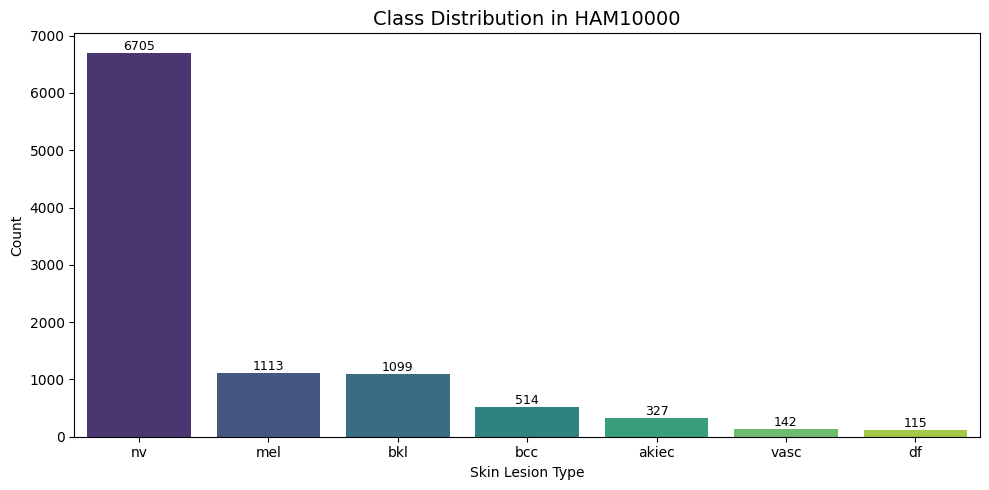

In [3]:
# --- Viz 1: Class Distribution ---
plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=df, palette='viridis',
              order=df['label_name'].value_counts().index)
plt.title('Class Distribution in HAM10000', fontsize=14)
plt.xlabel('Skin Lesion Type')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


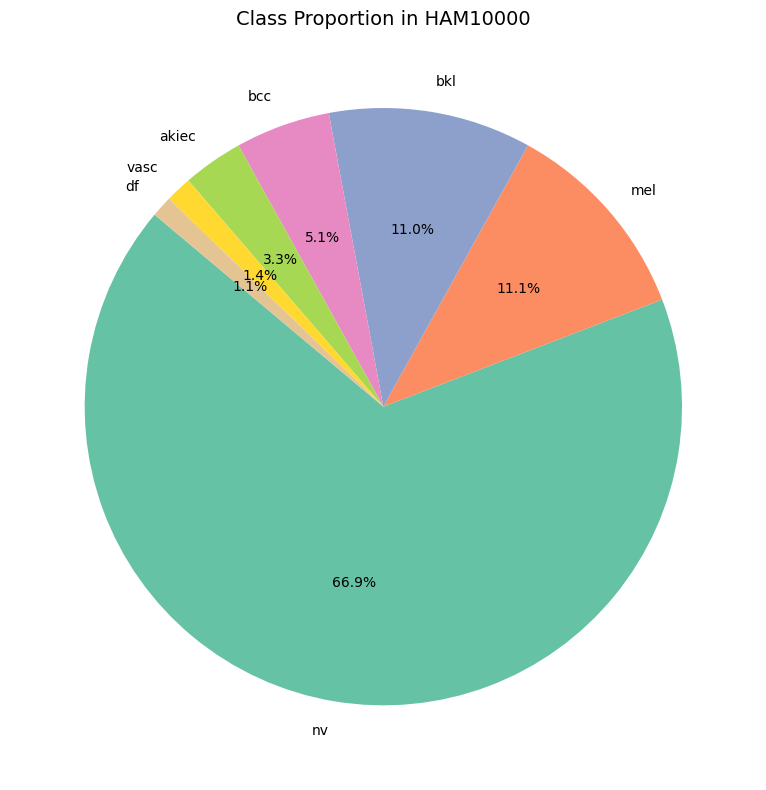

In [4]:
# --- Viz 2: Class Distribution Pie Chart ---
class_counts_viz = df['label_name'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(class_counts_viz.values,
        labels=class_counts_viz.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('Set2', len(class_counts_viz)))
plt.title('Class Proportion in HAM10000', fontsize=14)
plt.tight_layout()
plt.show()


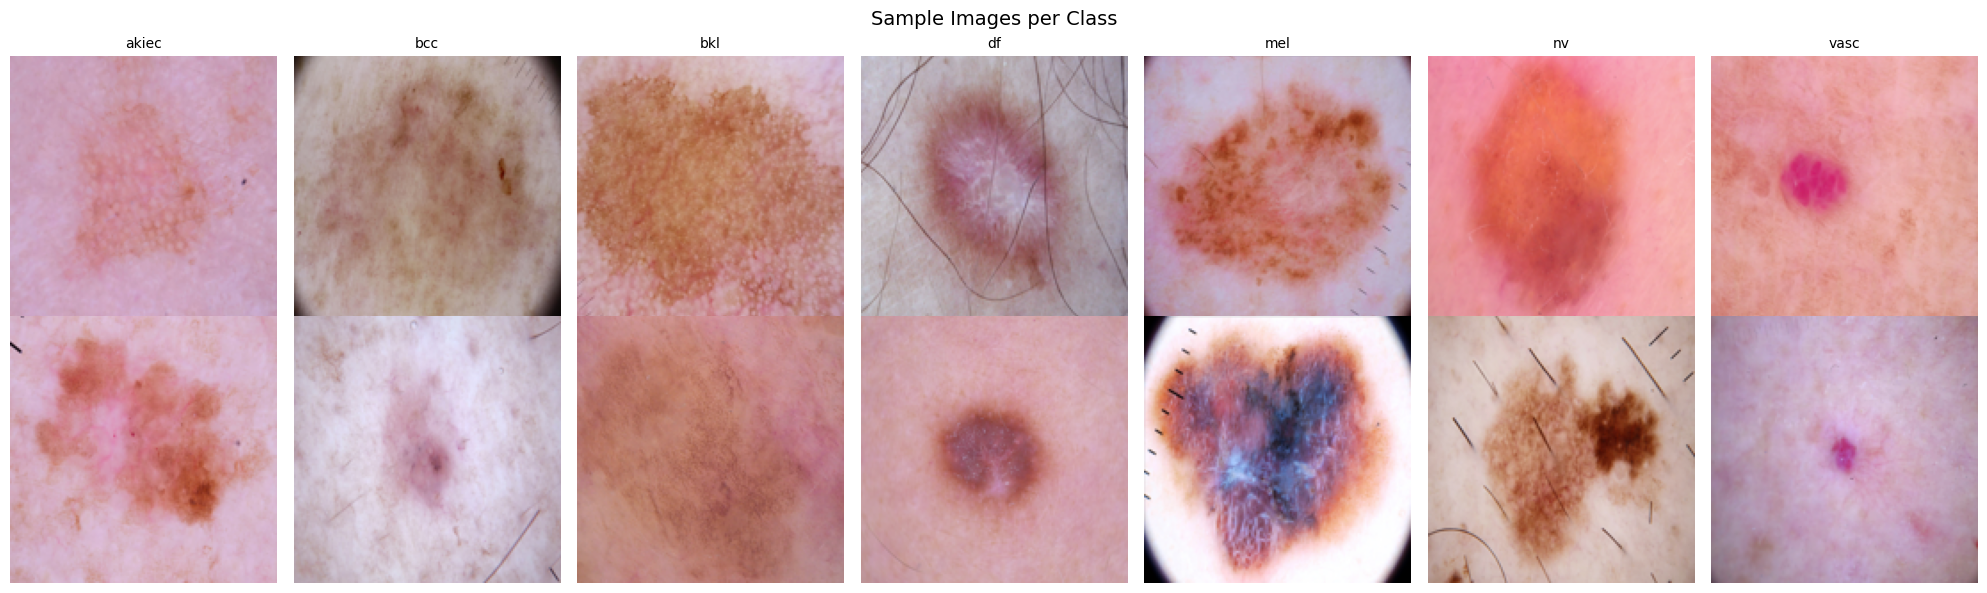

In [5]:
# --- Viz 3: Sample Images per Class (2 per class) ---
classes = df['label_name'].unique()
n_cols = 7
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6))
fig.suptitle('Sample Images per Class', fontsize=14)
for col_idx, cls in enumerate(sorted(classes)):
    samples = df[df['label_name'] == cls].sample(n_rows, random_state=42)
    for row_idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row['path']).convert('RGB').resize((150, 150))
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(cls, fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipykernel_58/339283477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_name', y='age', data=df,


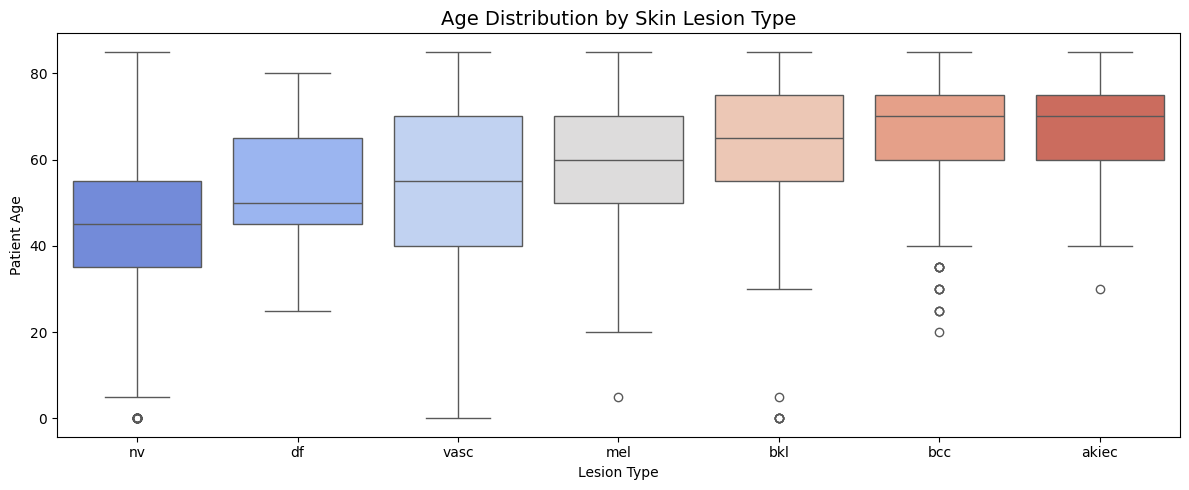

In [6]:
# --- Viz 4: Age Distribution by Class ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='label_name', y='age', data=df,
            palette='coolwarm',
            order=df.groupby('label_name')['age'].median().sort_values().index)
plt.title('Age Distribution by Skin Lesion Type', fontsize=14)
plt.xlabel('Lesion Type')
plt.ylabel('Patient Age')
plt.tight_layout()
plt.show()


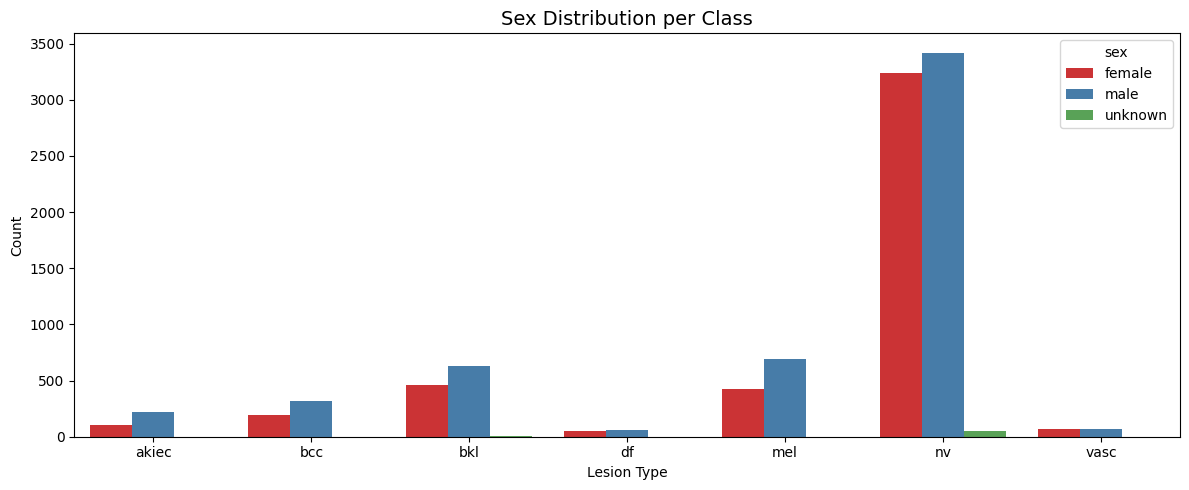

In [7]:
# --- Viz 5: Sex Distribution per Class ---
plt.figure(figsize=(12, 5))
sex_data = df.groupby(['label_name', 'sex']).size().reset_index(name='count')
sns.barplot(x='label_name', y='count', hue='sex',
            data=sex_data, palette='Set1')
plt.title('Sex Distribution per Class', fontsize=14)
plt.xlabel('Lesion Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


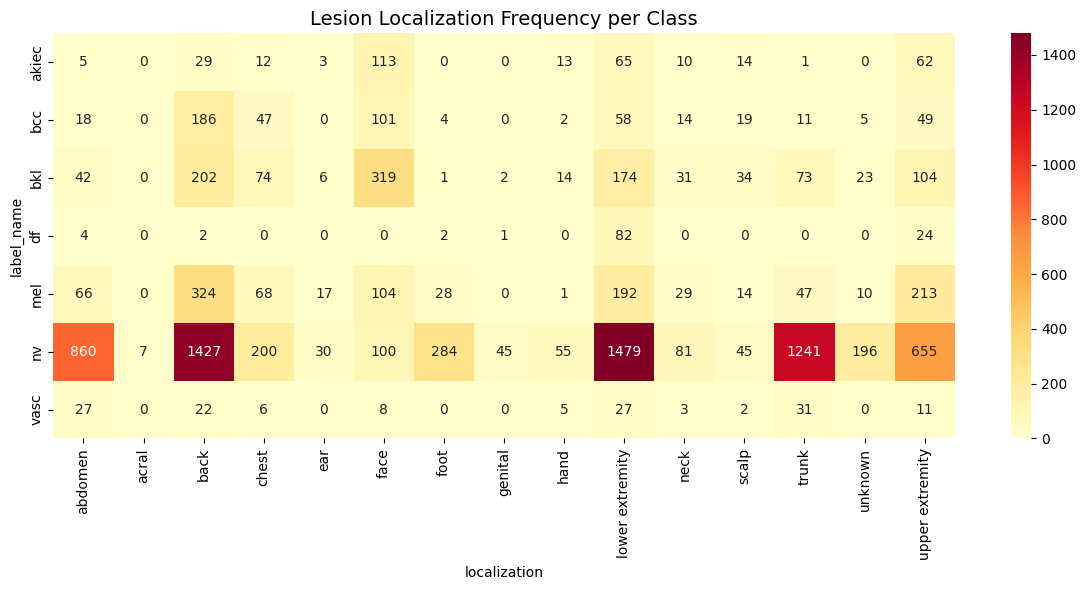

In [8]:
# --- Viz 6: Lesion Localization Frequency ---
plt.figure(figsize=(12, 6))
loc_pivot = df.groupby(['label_name', 'localization']).size().unstack(fill_value=0)
sns.heatmap(loc_pivot, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Lesion Localization Frequency per Class', fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_58/1125208351.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dx_type_counts.index, y=dx_type_counts.values, palette='magma')


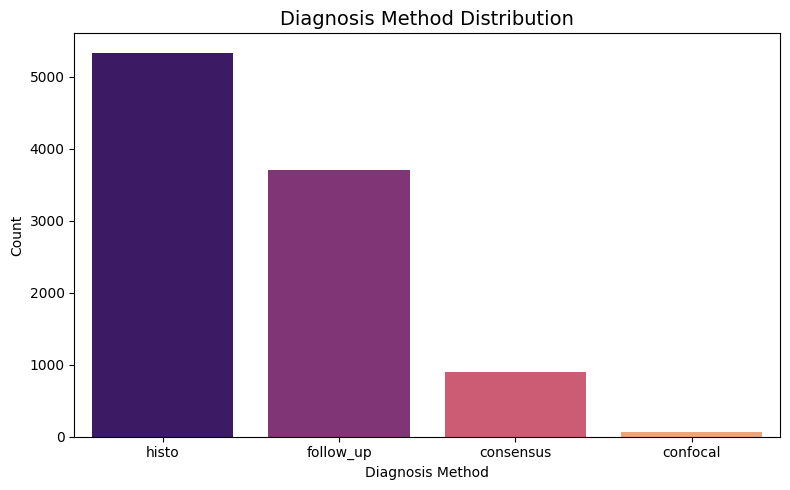

In [9]:
# --- Viz 7: Diagnosis Method Distribution ---
plt.figure(figsize=(8, 5))
dx_type_counts = df['dx_type'].value_counts()
sns.barplot(x=dx_type_counts.index, y=dx_type_counts.values, palette='magma')
plt.title('Diagnosis Method Distribution', fontsize=14)
plt.xlabel('Diagnosis Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


/tmp/ipykernel_58/3253807964.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  for _, row in df.groupby('label_name').apply(lambda x: x.sample(min(50, len(x)), random_state=42)).iterrows():
/tmp/ipykernel_58/3253807964.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label_name', y='mean_intensity', data=means_df, palette='pastel')


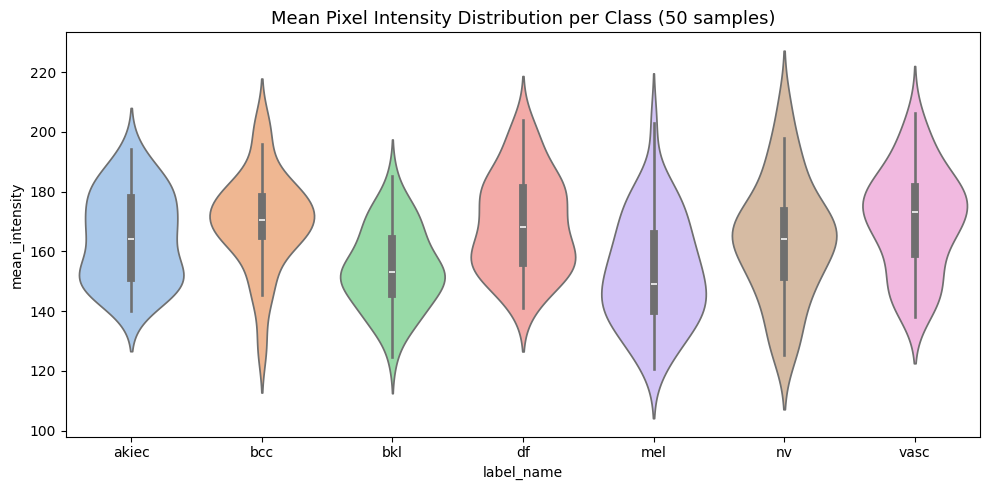

In [10]:
# --- Viz 8: Mean Pixel Intensity per Class (sample of 50 images) ---
means = []
for _, row in df.groupby('label_name').apply(lambda x: x.sample(min(50, len(x)), random_state=42)).iterrows():
    img = np.array(Image.open(row['path']).convert('RGB').resize((100, 100)))
    means.append({'label_name': row['label_name'], 'mean_intensity': img.mean()})
means_df = pd.DataFrame(means)
plt.figure(figsize=(10, 5))
sns.violinplot(x='label_name', y='mean_intensity', data=means_df, palette='pastel')
plt.title('Mean Pixel Intensity Distribution per Class (50 samples)', fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# تعريف التحويلات (Data Augmentation)
# ============================================================
IMG_SIZE = 300

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ============================================================
# Dataset Class
# ============================================================
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)  # ✅ fix: يمنع خطأ الـ index بعد الـ split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['path']
        image = Image.open(img_path).convert('RGB')
        label = torch.tensor(self.df.iloc[idx]['label_idx'], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

# ============================================================
# Train / Val Split + WeightedRandomSampler (يحل الـ Imbalance)
# ============================================================
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['label_idx'], random_state=42
)

# وزن كل sample بناءً على class
class_counts = train_df['label_idx'].value_counts().sort_index().values
weight_per_class = 1.0 / class_counts
sample_weights = train_df['label_idx'].map(
    dict(enumerate(weight_per_class))
).values

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    SkinDataset(train_df, train_transform),
    batch_size=32,
    sampler=sampler,       # ✅ بدل shuffle=True
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    SkinDataset(val_df, val_transform),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## 🏗️ Model Definitions: EfficientNetB3, ResNet50, DenseNet121

In [12]:
def build_efficientnet():
    model = models.efficientnet_b3(pretrained=True)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 7)
    )
    for name, param in model.named_parameters():
        if 'features' in name:
            param.requires_grad = False
    return model.to(device)


def build_resnet():
    model = models.resnet50(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 7)
    )
    # Freeze all except layer3, layer4, fc
    for name, param in model.named_parameters():
        if not any(layer in name for layer in ['layer3', 'layer4', 'fc']):
            param.requires_grad = False
    return model.to(device)


def build_densenet():
    model = models.densenet121(pretrained=True)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 7)
    )
    # Freeze early denseblocks
    for name, param in model.named_parameters():
        if 'denseblock1' in name or 'denseblock2' in name:
            param.requires_grad = False
    return model.to(device)


print('Model builders ready: EfficientNetB3 | ResNet50 | DenseNet121')


Model builders ready: EfficientNetB3 | ResNet50 | DenseNet121


## 🔁 Shared Training Loop

In [13]:
def train_model(model, model_name, epochs=50, unfreeze_epoch=10):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-4, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    best_val_acc = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        if epoch == unfreeze_epoch:
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

        # ── Train ──
        model.train()
        running_loss, correct = 0, 0
        for images, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        # ── Validate ──
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        t_acc = correct / len(train_loader.dataset)
        v_acc = val_correct / len(val_loader.dataset)
        t_loss = running_loss / len(train_loader)
        v_loss = val_loss / len(val_loader)

        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)

        print(f"[{model_name}] Epoch {epoch+1:02d} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"  ✅ Best model saved for {model_name}!")

        scheduler.step()

    print(f"\n🏆 Best Val Acc for {model_name}: {best_val_acc:.4f}")
    return history


## 🚀 Train EfficientNetB3

In [14]:
efficientnet = build_efficientnet()
history_eff = train_model(efficientnet, 'EfficientNetB3')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:01<00:00, 35.0MB/s]


EfficientNetB3 Epoch 1/50:   0%|          | 0/251 [00:00<?, ?it/s]

[EfficientNetB3] Epoch 01 | Train Loss: 1.8862 Acc: 0.2531 | Val Loss: 1.7531 Acc: 0.4998
  ✅ Best model saved for EfficientNetB3!


...

[EfficientNetB3] Epoch 48 | Train Loss: 0.5095 Acc: 0.9778 | Val Loss: 0.7024 Acc: 0.8932


EfficientNetB3 Epoch 49/50:   0%|          | 0/251 [00:00<?, ?it/s]

[EfficientNetB3] Epoch 49 | Train Loss: 0.5173 Acc: 0.9767 | Val Loss: 0.7027 Acc: 0.8892


EfficientNetB3 Epoch 50/50:   0%|          | 0/251 [00:00<?, ?it/s]

[EfficientNetB3] Epoch 50 | Train Loss: 0.5150 Acc: 0.9777 | Val Loss: 0.6795 Acc: 0.8982
  ✅ Best model saved for EfficientNetB3!

🏆 Best Val Acc for EfficientNetB3: 0.8982


In [29]:
from torchsummary import summary

# بناء الموديل
efficientnet_model = build_efficientnet()

# حساب إجمالي الـ parameters
total_params = sum(p.numel() for p in efficientnet_model.parameters())
trainable_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"{'='*45}")
print(f"  EfficientNet-B3 Parameter Summary")
print(f"{'='*45}")
print(f"  Total Parameters:     {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Frozen Parameters:    {frozen_params:,}")
print(f"{'='*45}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  EfficientNet-B3 Parameter Summary
  Total Parameters:     10,706,991
  Trainable Parameters: 10,759
  Frozen Parameters:    10,696,232


## 🚀 Train ResNet50

In [15]:
resnet = build_resnet()
history_res = train_model(resnet, 'ResNet50')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s] 


ResNet50 Epoch 1/50:   0%|          | 0/251 [00:00<?, ?it/s]

[ResNet50] Epoch 01 | Train Loss: 1.1915 Acc: 0.6462 | Val Loss: 1.2197 Acc: 0.6111
  ✅ Best model saved for ResNet50!


...

[ResNet50] Epoch 48 | Train Loss: 0.5153 Acc: 0.9739 | Val Loss: 0.7423 Acc: 0.8767


ResNet50 Epoch 49/50:   0%|          | 0/251 [00:00<?, ?it/s]

[ResNet50] Epoch 49 | Train Loss: 0.5125 Acc: 0.9758 | Val Loss: 0.7574 Acc: 0.8597


ResNet50 Epoch 50/50:   0%|          | 0/251 [00:00<?, ?it/s]

[ResNet50] Epoch 50 | Train Loss: 0.5116 Acc: 0.9765 | Val Loss: 0.7102 Acc: 0.8857

🏆 Best Val Acc for ResNet50: 0.8932


## 🚀 Train DenseNet121

In [16]:
densenet = build_densenet()
history_den = train_model(densenet, 'DenseNet121')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 30.8M/30.8M [00:00<00:00, 168MB/s]


DenseNet121 Epoch 1/50:   0%|          | 0/251 [00:00<?, ?it/s]

[DenseNet121] Epoch 01 | Train Loss: 1.2778 Acc: 0.5950 | Val Loss: 1.0956 Acc: 0.6835
  ✅ Best model saved for DenseNet121!


DenseNet121 Epoch 2/50:   0%|          | 0/251 [00:00<?, ?it/s]

...

[DenseNet121] Epoch 48 | Train Loss: 0.5245 Acc: 0.9722 | Val Loss: 0.7149 Acc: 0.8887


DenseNet121 Epoch 49/50:   0%|          | 0/251 [00:00<?, ?it/s]

[DenseNet121] Epoch 49 | Train Loss: 0.5185 Acc: 0.9747 | Val Loss: 0.7142 Acc: 0.8962


DenseNet121 Epoch 50/50:   0%|          | 0/251 [00:00<?, ?it/s]

[DenseNet121] Epoch 50 | Train Loss: 0.5259 Acc: 0.9704 | Val Loss: 0.7051 Acc: 0.8877

🏆 Best Val Acc for DenseNet121: 0.8962


## 📈 Individual Training Curves

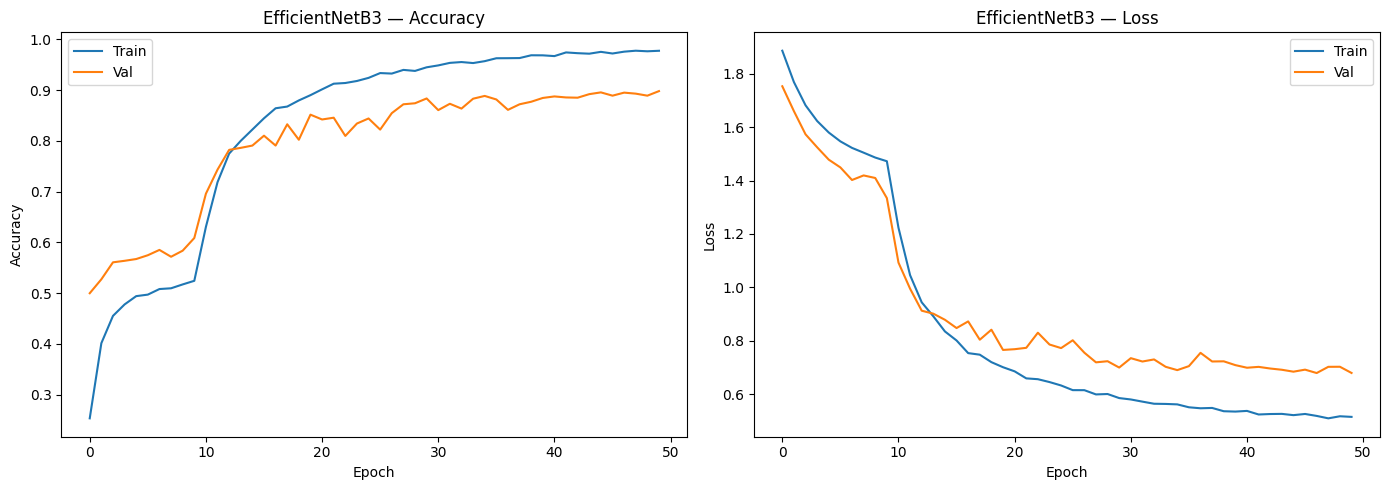

In [17]:
# EfficientNetB3 curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_eff['train_acc'], label='Train')
axes[0].plot(history_eff['val_acc'],   label='Val')
axes[0].set_title('EfficientNetB3 — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(history_eff['train_loss'], label='Train')
axes[1].plot(history_eff['val_loss'],   label='Val')
axes[1].set_title('EfficientNetB3 — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()


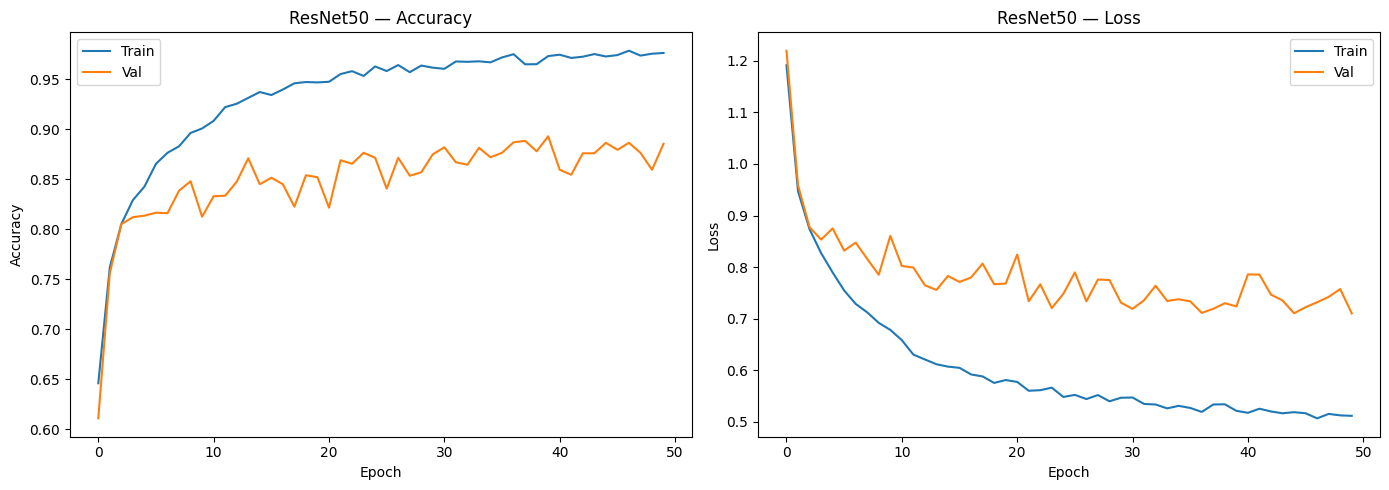

In [18]:
# ResNet50 curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_res['train_acc'], label='Train')
axes[0].plot(history_res['val_acc'],   label='Val')
axes[0].set_title('ResNet50 — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(history_res['train_loss'], label='Train')
axes[1].plot(history_res['val_loss'],   label='Val')
axes[1].set_title('ResNet50 — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()


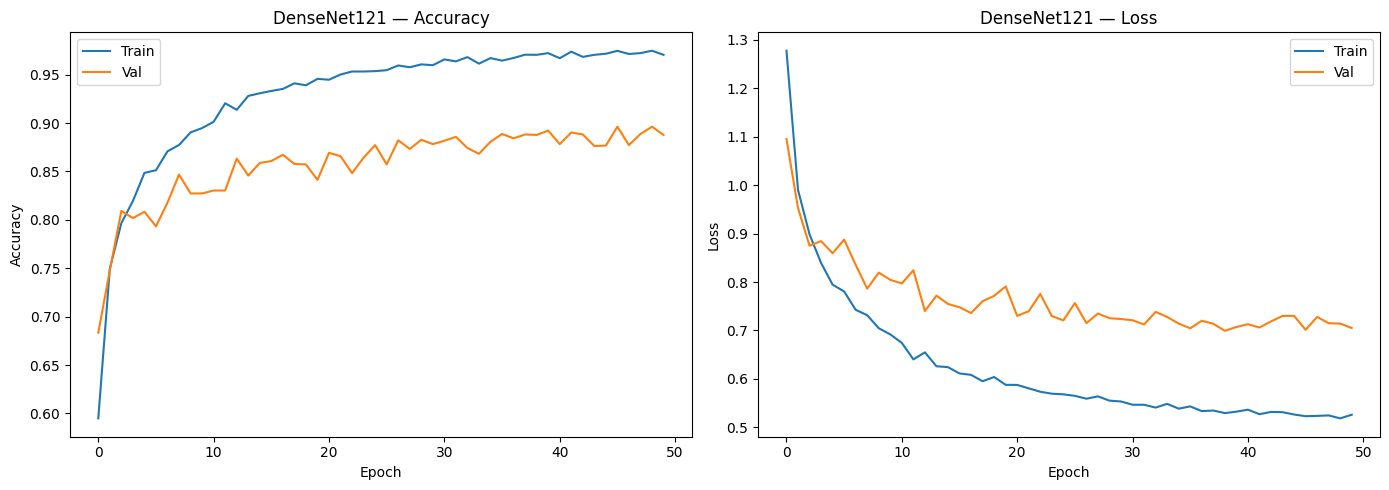

In [19]:
# DenseNet121 curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_den['train_acc'], label='Train')
axes[0].plot(history_den['val_acc'],   label='Val')
axes[0].set_title('DenseNet121 — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[1].plot(history_den['train_loss'], label='Train')
axes[1].plot(history_den['val_loss'],   label='Val')
axes[1].set_title('DenseNet121 — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()


## ⚖️ Model Comparison

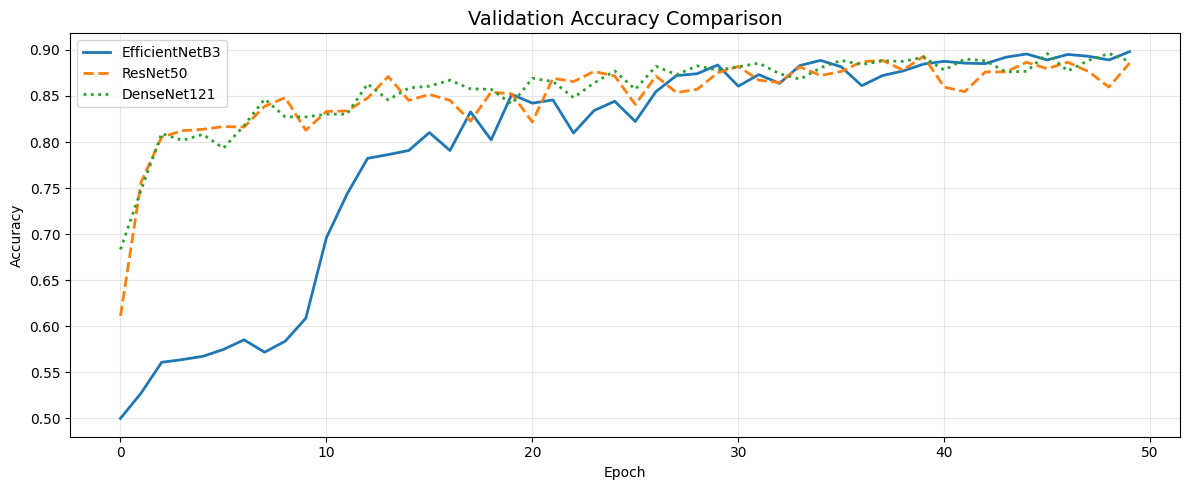

In [20]:
# --- Comparison 1: Validation Accuracy over Epochs ---
plt.figure(figsize=(12, 5))
plt.plot(history_eff['val_acc'], label='EfficientNetB3', linewidth=2)
plt.plot(history_res['val_acc'], label='ResNet50',       linewidth=2, linestyle='--')
plt.plot(history_den['val_acc'], label='DenseNet121',    linewidth=2, linestyle=':')
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


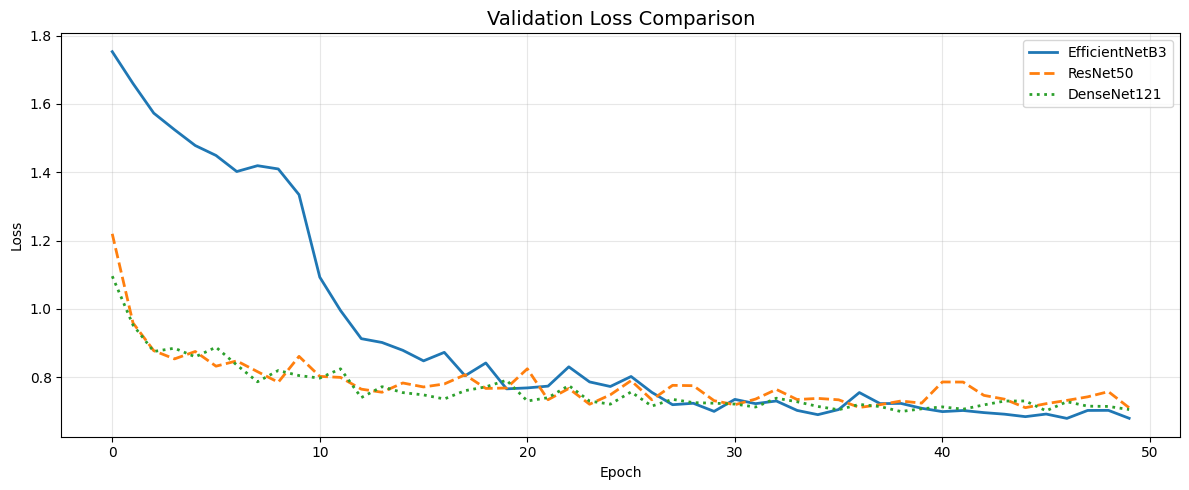

In [21]:
# --- Comparison 2: Validation Loss over Epochs ---
plt.figure(figsize=(12, 5))
plt.plot(history_eff['val_loss'], label='EfficientNetB3', linewidth=2)
plt.plot(history_res['val_loss'], label='ResNet50',       linewidth=2, linestyle='--')
plt.plot(history_den['val_loss'], label='DenseNet121',    linewidth=2, linestyle=':')
plt.title('Validation Loss Comparison', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


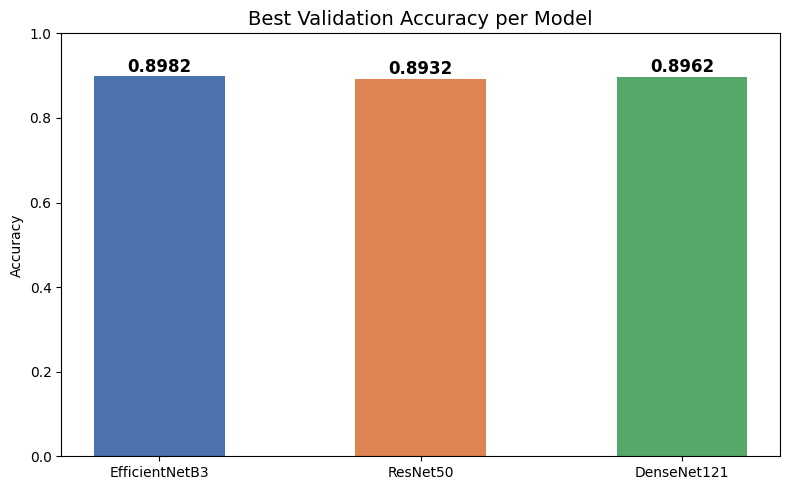

In [22]:
# --- Comparison 3: Best Val Accuracy Bar Chart ---
model_names = ['EfficientNetB3', 'ResNet50', 'DenseNet121']
best_accs = [
    max(history_eff['val_acc']),
    max(history_res['val_acc']),
    max(history_den['val_acc']),
]
colors = ['#4C72B0', '#DD8452', '#55A868']
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, best_accs, color=colors, width=0.5)
for bar, acc in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Best Validation Accuracy per Model', fontsize=14)
plt.ylabel('Accuracy'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()


## 📋 Per-Model Evaluation: Classification Report & Confusion Matrix

=== EfficientNetB3 Classification Report ===
              precision    recall  f1-score   support

       akiec       0.82      0.75      0.78        65
         bcc       0.84      0.93      0.88       103
         bkl       0.87      0.71      0.78       220
          df       1.00      0.83      0.90        23
         mel       0.73      0.72      0.73       223
          nv       0.93      0.97      0.95      1341
        vasc       1.00      0.82      0.90        28

    accuracy                           0.90      2003
   macro avg       0.88      0.82      0.85      2003
weighted avg       0.90      0.90      0.90      2003



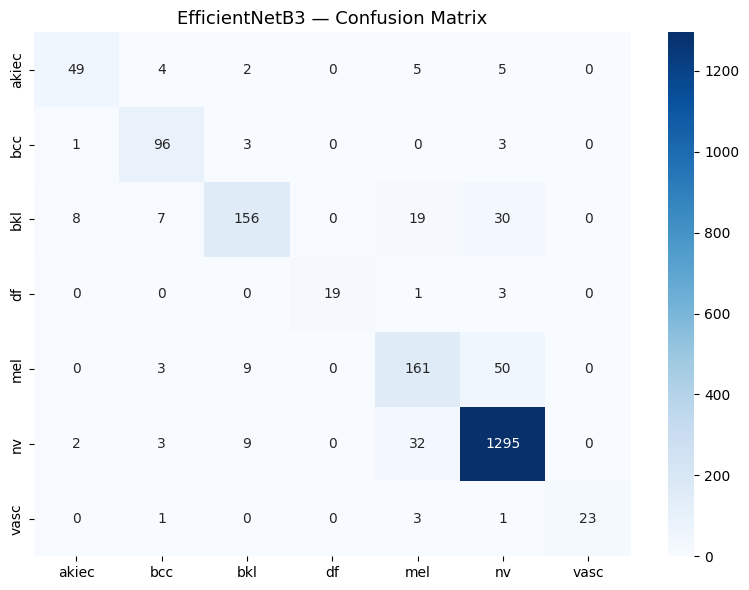

In [23]:
# ─── EfficientNetB3 ───
model_eval = build_efficientnet()
model_eval.load_state_dict(torch.load('best_EfficientNetB3.pth', map_location=device))
model_eval.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_eval(images)
        y_true.extend(labels.numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
print(f'=== EfficientNetB3 Classification Report ===')
print(classification_report(y_true, y_pred, target_names=list(label_names.values())))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names.values(), yticklabels=label_names.values())
plt.title('EfficientNetB3 — Confusion Matrix', fontsize=13)
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== ResNet50 Classification Report ===
              precision    recall  f1-score   support

       akiec       0.91      0.74      0.81        65
         bcc       0.89      0.90      0.89       103
         bkl       0.74      0.87      0.80       220
          df       1.00      0.96      0.98        23
         mel       0.71      0.69      0.70       223
          nv       0.95      0.94      0.94      1341
        vasc       1.00      0.93      0.96        28

    accuracy                           0.89      2003
   macro avg       0.88      0.86      0.87      2003
weighted avg       0.90      0.89      0.89      2003



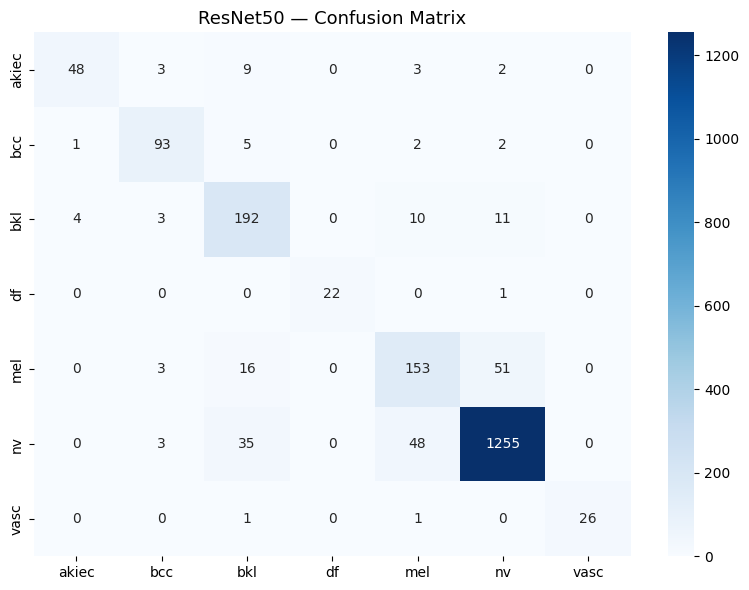

In [24]:
# ─── ResNet50 ───
model_eval = build_resnet()
model_eval.load_state_dict(torch.load('best_ResNet50.pth', map_location=device))
model_eval.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_eval(images)
        y_true.extend(labels.numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
print(f'=== ResNet50 Classification Report ===')
print(classification_report(y_true, y_pred, target_names=list(label_names.values())))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names.values(), yticklabels=label_names.values())
plt.title('ResNet50 — Confusion Matrix', fontsize=13)
plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


=== DenseNet121 Classification Report ===
              precision    recall  f1-score   support

       akiec       0.73      0.75      0.74        65
         bcc       0.86      0.95      0.90       103
         bkl       0.82      0.79      0.80       220
          df       0.95      0.83      0.88        23
         mel       0.79      0.61      0.69       223
          nv       0.93      0.97      0.95      1341
        vasc       0.87      0.93      0.90        28

    accuracy                           0.90      2003
   macro avg       0.85      0.83      0.84      2003
weighted avg       0.89      0.90      0.89      2003



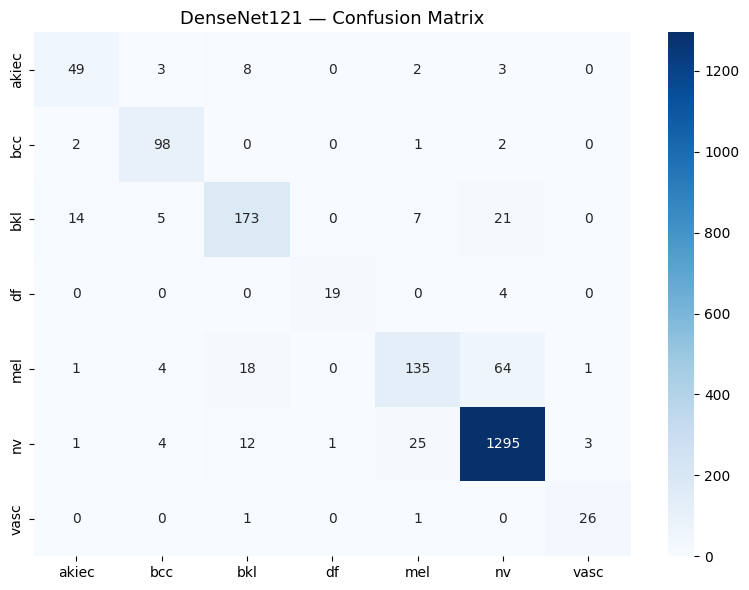

In [25]:
# ─── DenseNet121 ───
model_eval = build_densenet()
model_eval.load_state_dict(torch.load('best_DenseNet121.pth', map_location=device))
model_eval.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_eval(images)
        y_true.extend(labels.numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
print(f'=== DenseNet121 Classification Report ===')
print(classification_report(y_true, y_pred, target_names=list(label_names.values())))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names.values(), yticklabels=label_names.values())
plt.title('DenseNet121 — Confusion Matrix', fontsize=13)
plt.tight_layout(); plt.show()


## 📊 Full Comparison Summary Table

In [26]:
from sklearn.metrics import accuracy_score, f1_score

summary_rows = []
for mname, build_fn in [('EfficientNetB3', build_efficientnet),
                          ('ResNet50', build_resnet),
                          ('DenseNet121', build_densenet)]:
    m = build_fn()
    m.load_state_dict(torch.load(f'best_{mname}.pth', map_location=device))
    m.eval()
    yt, yp = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(device)
            out = m(imgs)
            yt.extend(lbls.numpy())
            yp.extend(out.argmax(1).cpu().numpy())
    acc  = accuracy_score(yt, yp)
    f1_w = f1_score(yt, yp, average='weighted')
    f1_m = f1_score(yt, yp, average='macro')
    summary_rows.append({'Model': mname, 'Val Accuracy': f'{acc:.4f}',
                          'Weighted F1': f'{f1_w:.4f}', 'Macro F1': f'{f1_m:.4f}'})

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df.to_string())


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weight

               Val Accuracy Weighted F1 Macro F1
Model                                           
EfficientNetB3       0.8982      0.8962   0.8474
ResNet50             0.8932      0.8938   0.8700
DenseNet121          0.8962      0.8926   0.8373


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weight

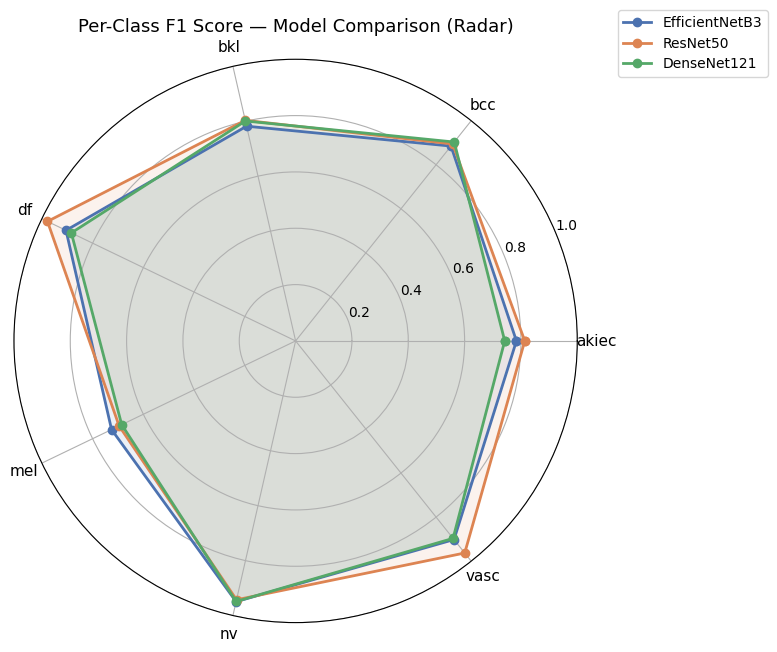

In [27]:
# --- Radar / Spider Chart: Weighted F1 per class ---
from sklearn.metrics import classification_report
import numpy as np

all_reports = {}
for mname, build_fn in [('EfficientNetB3', build_efficientnet),
                          ('ResNet50', build_resnet),
                          ('DenseNet121', build_densenet)]:
    m = build_fn()
    m.load_state_dict(torch.load(f'best_{mname}.pth', map_location=device))
    m.eval()
    yt, yp = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(device)
            out = m(imgs)
            yt.extend(lbls.numpy())
            yp.extend(out.argmax(1).cpu().numpy())
    rep = classification_report(yt, yp, target_names=list(label_names.values()), output_dict=True)
    all_reports[mname] = [rep[c]['f1-score'] for c in label_names.values()]

categories = list(label_names.values())
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = ['#4C72B0', '#DD8452', '#55A868']
for (mname, vals), col in zip(all_reports.items(), colors_r):
    vals = vals + vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=mname, color=col)
    ax.fill(angles, vals, alpha=0.1, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Per-Class F1 Score — Model Comparison (Radar)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout(); plt.show()


## 🔍 Predict External Image

In [28]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

def predict_external_image(image_path, model_path='best_skin_model.pth'):
    # 1. تعريف أسماء الفئات (نفس الترتيب المستخدم في التدريب)
    label_names = {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}
    
    # 2. تحديد المعالجة المطلوبة للصورة (يجب أن تطابق val_transform)
    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 3. تحميل الصورة ومعالجتها
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0) # إضافة dimension للـ batch
    
    # 4. بناء النموذج وتحميل الأوزان المحفوظة
    # تأكد أنك تستخدم نفس بناء النموذج (مثلاً EfficientNetB0)
    from torchvision import models
    model = models.efficientnet_b0(pretrained=False)
    in_features = model.classifier[1].in_features
    model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(0.4),
        torch.nn.Linear(in_features, 7)
    )
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    # 5. التوقع (Inference)
    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    # 6. عرض النتيجة
    result = label_names[predicted_idx.item()]
    conf_score = confidence.item() * 100
    
    plt.imshow(image)
    plt.title(f"Prediction: {result} ({conf_score:.2f}%)")
    plt.axis('off')
    plt.show()
    
    return result, conf_score

# --- طريقة الاستخدام ---
# استبدل 'test_image.jpg' بمسار الصورة الخارجية عندك
result, score = predict_external_image('/kaggle/input/datasets/omarsalman77/private-test/Melanoma.jpg')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'best_skin_model.pth'